In [1]:
import base64
import io
import pickle
import functools
import itertools

import jax.numpy as jnp
import jax
jax.config.update("jax_platforms", "cpu")
jax.config.update("jax_debug_key_reuse", True)

# set cache size to 1GB
jax.config.update("jax_compilation_cache_max_size", 2**30 - 1)

# jax.config.update("jax_log_compiles", True)
# jax.config.update("jax_compiler_detailed_logging_min_ops", 50)

# jax.config.update("jax_explain_cache_misses", True)
# jax.config.update("jax_check_tracer_leaks", True)
# jax.config.update("jax_debug_nans", True)

import orthax

import matplotlib
import matplotlib.pyplot as plt
# import matplotlib.animation as animation
import pandas as pd



In [2]:
def scatter_vector(theta, lambda_0=633e-9, n=1.33, radians=False):
    if not radians:
        theta = jnp.radians(theta)
    return (4 * jnp.pi * n/lambda_0) * jnp.sin(theta / 2)

def diffusion_coef(r, k_B=1.38e-23, T=298.15, eta=0.00089):
    """
    r - particle radius
    k_b - Boltzmann constant (J/K)
    T - Temperature (K)
    eta - Viscosity of water at room temerature (Pa*s)
    """
    return k_B * T / (6 * jnp.pi * eta * r)

def prep_data_g2(datafile):
    df = pd.read_csv(datafile, delimiter='\t', header=None)
    df = df.iloc[1:] # remove strange first point
    d = jnp.array(df.to_numpy())

    t = d[:, 0]
    t *=  1e-3 # convert timestamps from ms to s
    g2_minus1_obs = d[:, 1:].T
    theta = jnp.arange(30., 151, 5) # angles known in advance - in degrees
    q = scatter_vector(theta)
    div = jax.vmap(lambda x: x/x[0])
    g1_squared = div(g2_minus1_obs) # normalization by first term handles removing the beta term (roughly)

    return q, t, g1_squared



In [3]:
name_file_map = {
    "100nm": "stock_100nm",
    "200nm": "stock_200nm",
    "500nm": "stock_500nm",
    "1000nm": "stock_1000nm",
    "mix_1": "mix_1",
    "mix_2": "mix_2",
    "mix_3": "mix_3",
    "mix_4": "mix_4",
    "mix_5": "mix_5",
    "mix_6": "mix_6",
    "mix_7": "mix_7",
    "mix_8": "mix_8",
    "mix_9": "mix_9",
    "mix_10": "mix_10",
    "mix_11": "mix_11",
    "mix_12": "mix_12",
    "mix_13": "mix_13",
    "mix_14": "mix_14",
    "mix_15": "mix_15",
}


| dia. nm                | 100          | 200         | 500         | 1000      | 0        |
|------------------------|--------------|-------------|-------------|-----------|----------|
|                        |              |             |             |           | 1mM NaCl |
| stock (solid fraction) | 1.998E-05    | 1.998E-05   | 1.998E-05   | 9.995E-06 | 0        |
| name                   | volumes (mL) |             |             |           |          |
| stock_100nm            | 1            | 0           | 0           | 0         | 0        |
| stock_200nm            | 0            | 1           | 0           | 0         | 0        |
| stock_500nm            | 0            | 0           | 1           | 0         | 0        |
| stock_1000nm           | 0            | 0           | 0           | 1         | 0        |
| mix_1                  | 0            | 0.8         | 0           | 0.2       | 0        |
| mix_2                  | 0            | 0.8         | 0           | 0.2       | 0.25     |
| mix_3                  | 0            | 0.8         | 0           | 0.2       | 1        |
| mix_4                  | 0            | 0.8         | 0           | 0.2       | 3        |
| mix_5                  | 0.333333333  | 0.333333333 | 0.333333333 | 0         | 0        |
| mix_6                  | 0.333333333  | 0.333333333 | 0.333333333 | 0         | 0.25     |
| mix_7                  | 0.333333333  | 0.333333333 | 0.333333333 | 0         | 1        |
| mix_8                  | 0.333333333  | 0.333333333 | 0.333333333 | 0         | 3        |
| mix_9                  | 0.333333333  | 0.333333333 | 0.333333333 | 0         | 9        |
| mix_10                 | 0.25         | 0.25        | 0.25        | 0.25      | 0        |
| mix_11                 | 0.25         | 0.25        | 0.25        | 0.25      | 0.25     |
| mix_12                 | 0.25         | 0.25        | 0.25        | 0.25      | 1        |
| mix_13                 | 0.25         | 0.25        | 0.25        | 0.25      | 3        |
| mix_14                 | 0.25         | 0.25        | 0.25        | 0.25      | 9        |
| mix_15                 | 0.25         | 0.25        | 0.25        | 0.25      | 19       |

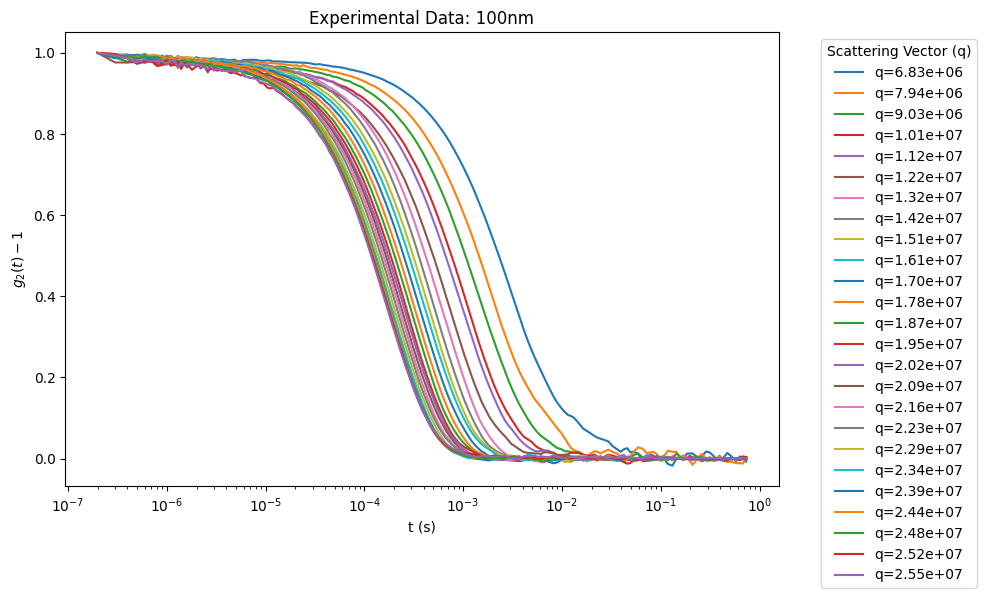

In [4]:
import os

base_path = os.path.expanduser("~/repos/DLS/Experimental_data_083122/")

for name, file_prefix in name_file_map.items():
    file_path = os.path.join(base_path, f"{file_prefix}.csv")
    
    if not os.path.exists(file_path):
        print(f"File not found, skipping: {file_path}")
        continue

    q, t, exp0 = prep_data_g2(file_path)
    
    fig, ax = plt.subplots(figsize=(10, 6))

    for i in range(exp0.shape[0]):
        ax.plot(t, exp0[i], label=f'q={q[i]:.2e}')

    ax.set_xlabel("t (s)")
    ax.set_ylabel("$g_2(t) - 1$")
    ax.set_title(f"Experimental Data: {name}")
    ax.set_xscale('log')
    ax.legend(title="Scattering Vector (q)", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    break